# Regression Tree

A Decision Tree Regressor is used to predict continuous numerical values (e.g., price, age, temperature).

The tree splits the dataset based on input features to minimize variance or error in the output (target variable).

# Decision Tree:
 A decision tree builds regression or classification models in the form of a tree structure. It breaks down a dataset into smaller and smaller subsets while at the same time an associated decision treee in incremetally developed.The final result is a tree with decision nodes and leaf nodes.

Decision tress can handle both categorical and numerical data.

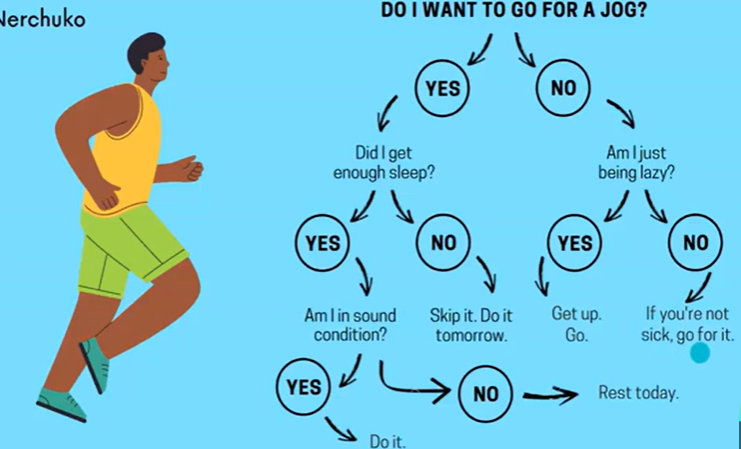

In [3]:
from PIL import Image
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-07-09 202959.png")

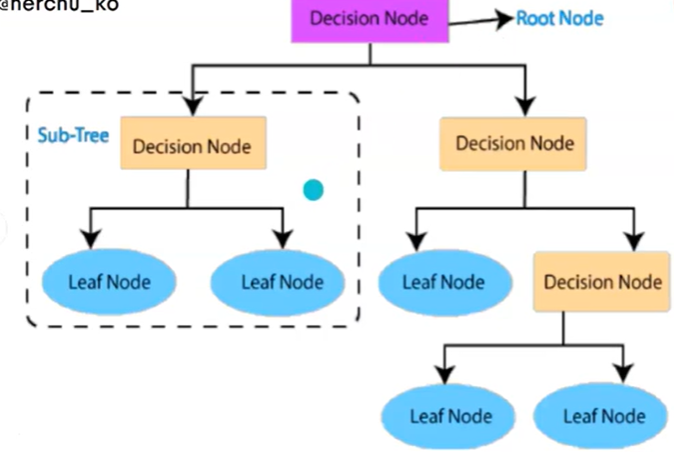

In [4]:
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-07-09 203031.png")

### Regression Tree:
for continuous quantitative target variable.
##### Eg: predicting rainfall, predicting revenue, predicting marks etc.
### Classification Tree:
for discrete categorical target variables.
##### Eg: predicting high or low, win or loss. healthy or Unhealthy etc.

#### Algorithms: ID3 alg=entropy, inf gain, CART alg=gini impurity calculated. then  decision tree build

# HOW TO BUILD REGRESSION TREES?

# 2 TYPES HAVE:

## 1.Standard Deviation Reduction

## 2.Sum Of Squares Of Residual Error


# 1. Standard Deviation Reduction (SDR) – Used to choose the best split

 What Is It?
 
SDR is used during the tree building phase to evaluate how good a split is.

It helps answer:

“If I split the data on this feature, will the prediction variance reduce?”



Step-by-Step Process:
    
1.At a node, calculate the Standard Deviation of the target values (before split).

2.Try all possible splits on each feature.

3.For each split:

* Split the data into Left and Right
* Calculate the weighted average standard deviation of the children

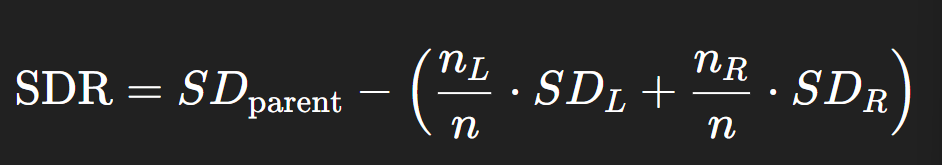

In [6]:
Image.open(r"C:\Users\Windows\OneDrive\Pictures\Screenshots\Screenshot 2025-07-09 205527.png")

4.Pick the split with the highest SDR, because it reduces the uncertainty the most.

Example:

| Parent values: [100, 102, 98, 97, 103] → SD = ~2.3 |

Split by feature A gives:

* Left: [100, 102, 103] → SD = 1.2

* Right: [97, 98] → SD = 0.7

Weighted average SD = 1.0

SDR = 2.3 - 1.0 = 1.3 → Good split



2. Sum of Squares of Residuals (SSR / SSE) – Used to evaluate prediction quality

# How to Avoid overfitting
limit the depth of the tree

limit the number of samples on the leaf

# Advantages of Decision Tree Regression

* Easy to Understand and Interpret

* No Need for Feature Scaling

* Handles Both Categorical and Numerical Data

* Captures Non-linear Relationships

* Automatic Feature Selection

* Handles Missing Values (to some extent)

# Disadvantages of Decision Tree Regression

* Prone to Overfitting
    
* Hard to Capture Smooth Functions

* Biased Toward Features with More Levels

* Unstable with Small Change


# Decision Tree (Implementation)

In [247]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# load the data

In [248]:

df=pd.read_csv(r"C:\Users\Windows\Downloads\Data.csv")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [249]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [250]:
df.shape


(9568, 5)

In [251]:
df.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [252]:
X=df.iloc[:,:-1].values
Y=df[['PE']]

# Splitting the Data as train and test

In [253]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(X, Y, test_size=0.2, random_state=0)

# Train the model

In [254]:
from sklearn.tree import DecisionTreeRegressor,plot_tree
rg=DecisionTreeRegressor(max_depth=3, random_state=42)
rg.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [255]:
# Predictions
y_pred = rg.predict(x_test)  
y_pred

array([434.70649887, 461.29894737, 468.23847047, ..., 468.23847047,
       442.70435374, 461.29894737])

In [256]:
score = r2_score(y_test, y_pred)
print("R² Score:", score)

R² Score: 0.9150146758808587


In [257]:


# Check shapes (both should be 1D arrays of same length)
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)


y_test shape: (1914, 1)
y_pred shape: (1914,)


# Visualize the tree

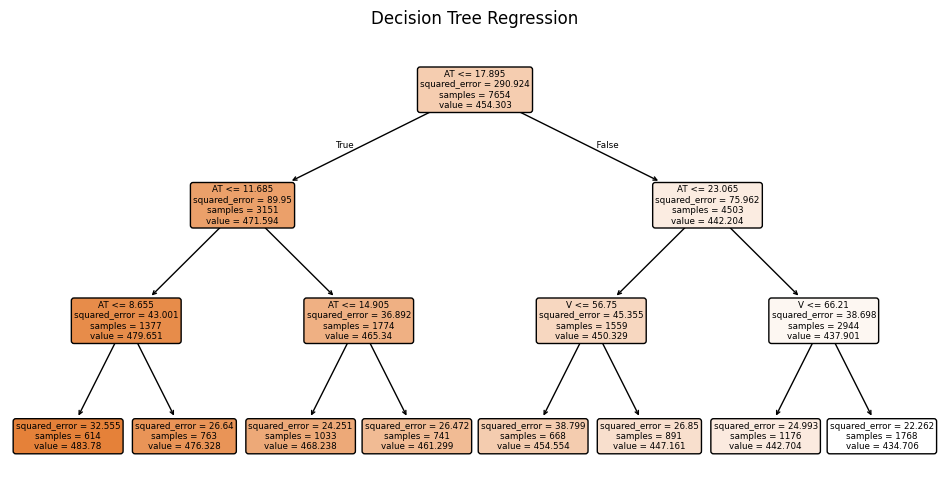

In [147]:

plt.figure(figsize=(12, 6))
plot_tree(rg, filled=True, feature_names=['AT', 'V', 'AP', 'RH'], rounded=True)
plt.title("Decision Tree Regression")
plt.show()